# Naive Bayesian discriminant

See: https://scikit-learn.org/stable/modules/naive_bayes.html

Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import numpy as np
from array import array
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

### (1) Define 2D sample generation procedure

In [2]:
# Generate 2D normal distributed sample using method from lecture 4

def mydata(Nmc,pos,sig,corr=0.0):

    data = np.empty(shape=(Nmc,2))
    
    phi = 0.5*np.arcsin(corr)

    g = np.random.normal(size=(2,Nmc))

    data[:,0] = pos[0] + sig[0]*(g[0]*np.cos(phi) + g[1]*np.sin(phi))
    data[:,1] = pos[1] + sig[1]*(g[0]*np.sin(phi) + g[1]*np.cos(phi))
    
    return data

### (2) Generating train and test data

In [64]:
# Sample size

Ntrain = 100
Ntest  = 100

# Two hypothesis

h1 = np.array([-1.,-1.])
h2 = np.array([1.,1.])

# Fraction of first hypothesis

fh1 = 0.1

# Measurement uncertainties

sig = np.array([1.2,0.6])
corr = 0.0

# Generate train sample 
# ---------------------

h1train = mydata(Ntrain,h1,sig,corr)
h2train = mydata(Ntrain,h2,sig,corr)

# Uniform distributed numbers

rtrain = np.random.uniform(size=Ntrain)

# Mix of two hypothesis

y_train = rtrain > fh1

y2_train = np.resize(np.repeat(y_train,2),(Ntrain,2))

X_train = y2_train * h1train + (1 - y2_train)*h2train

print("Train data defined, size: ",y_train.size)

# Generate test sample 
# --------------------

h1test = mydata(Ntest,h1,sig,corr)
h2test = mydata(Ntest,h2,sig,corr)

# Uniform distributed numbers

rtest = np.random.uniform(size=Ntest)

# Mix of two hypothesis

y_test = rtest > fh1

y2_test = np.resize(np.repeat(y_test,2),(Ntest,2))

X_test = y2_test * h1test + (1 - y2_test)*h2test

print("Test data defined, size: ",y_test.size)


Train data defined, size:  100
Test data defined, size:  100


### (3) Bayesian classifier assuming Gaussian distributions

In [65]:
# Define classifier

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_train_pred = gnb.predict(X_train)

print("Number of mislabeled training points out of a total %d points : %d"
        % (X_train.shape[0], (y_train != y_train_pred).sum()))

y_test_pred = gnb.predict(X_test)

print("Number of mislabeled test points out of a total %d points : %d"
        % (X_test.shape[0], (y_test != y_test_pred).sum()))


Number of mislabeled training points out of a total 100 points : 2
Number of mislabeled test points out of a total 100 points : 3


### (4) Plot results

In [66]:
# 2D grid for decision histogram (as background)

Xmin = -5.0
Xmax = 5.0
Nbin = 100
dX = (Xmax-Xmin)/Nbin

Xrange = np.linspace(Xmin+0.5*dX,Xmax-0.5*dX,Nbin)

X1grid, X2grid = np.meshgrid(Xrange,Xrange)

# Change 2D grids to array of (x1,x2) pairs, required input format for predict()

X1vec = np.reshape(X1grid,Nbin*Nbin)
X2vec = np.reshape(X2grid,Nbin*Nbin)

Xvec = np.transpose([X1vec,X2vec])

# Calculate classifier predictions

Yvec = gnb.predict(Xvec)


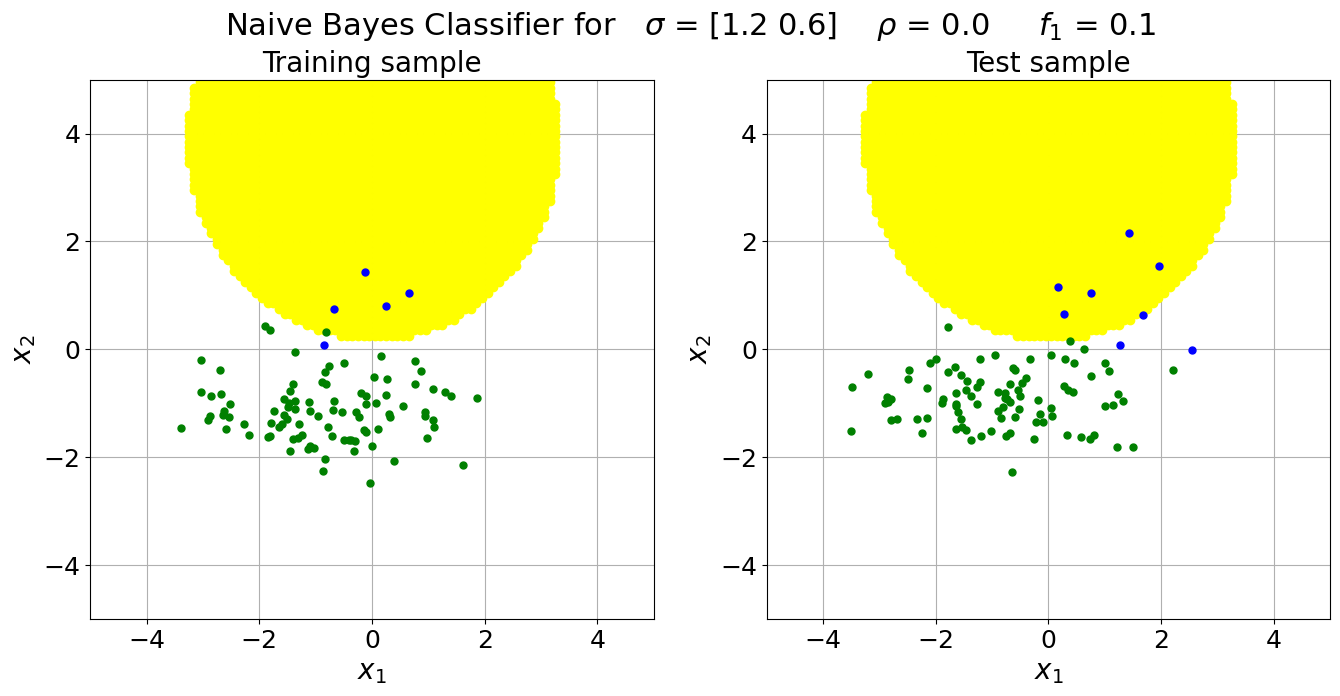

In [67]:
# Create result graph

plt.subplots(1,2,figsize=(16, 7))

plt.suptitle("Naive Bayes Classifier for   $\\sigma$ = "+str(sig)+'    $\\rho$ = '+str(corr)+"     $f_{1}$ = "+str(fh1),fontsize=22)

# Train sample

plt.subplot(121)

# Decision pattern as background

plt.plot(X1vec[Yvec==0],X2vec[Yvec==0],'o',color='yellow')
plt.xlim([Xmin,Xmax])
plt.ylim([Xmin,Xmax])

# Training points in two categories

plt.plot(X_train[:,0][y_train==0],X_train[:,1][y_train==0],'o',color='blue',ms=5)
plt.plot(X_train[:,0][y_train==1],X_train[:,1][y_train==1],'o',color='green',ms=5)

plt.title("Training sample",size=20)
plt.xlabel('$x_1$',size=20)
plt.ylabel('$x_2$',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')

# Test sample

plt.subplot(122)

# Decision pattern as background

plt.plot(X1vec[Yvec==0],X2vec[Yvec==0],'o',color='yellow')
plt.xlim([Xmin,Xmax])
plt.ylim([Xmin,Xmax])

# Test points in two categories

plt.plot(X_test[:,0][y_test==0],X_test[:,1][y_test==0],'o',color='blue',ms=5)
plt.plot(X_test[:,0][y_test==1],X_test[:,1][y_test==1],'o',color='green',ms=5)

plt.title("Test sample",size=20)
plt.xlabel('$x_1$',size=20)
plt.ylabel('$x_2$',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')


fname = '12_Bayes_'+str(sig[0])+'_'+str(sig[1])+'_'+str(corr)+'_'+str(fh1)+'.png'

plt.savefig(fname)

plt.show()